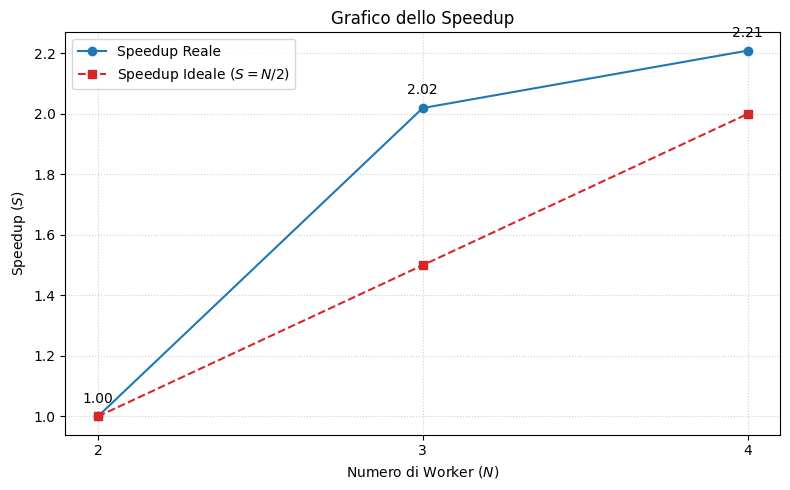

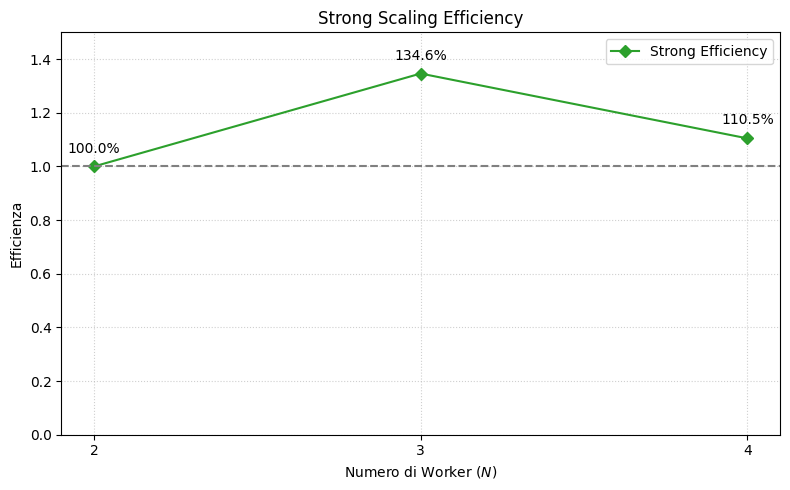

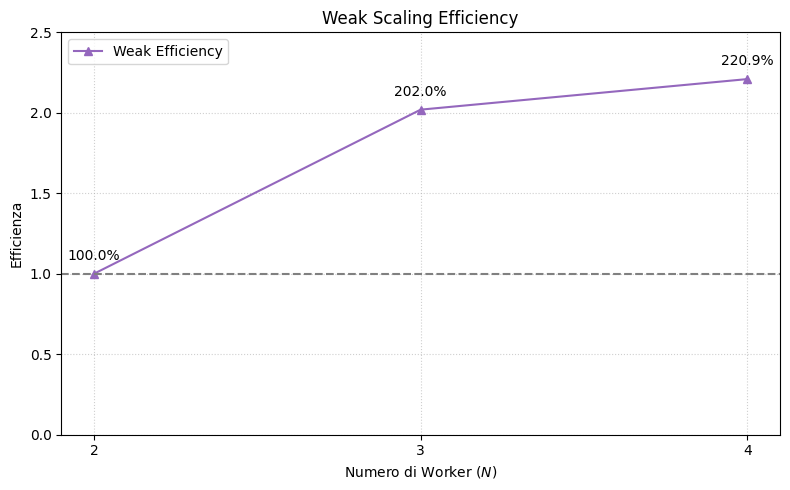

In [1]:
import matplotlib.pyplot as plt
import numpy as np

#Definizione dei dati
workers = np.array([2, 3, 4])
tempi = np.array([665.772, 329.649, 301.324])

# Costanti per il calcolo
t1_stimato = tempi[0] * 2  # Stima T(1) dal baseline a 2 worker

# --- CALCOLI ---
# Speedup
speedup_reale = tempi[0] / tempi
speedup_ideale = workers / 2

# Strong Scaling Efficiency
strong_efficiency = t1_stimato / (workers * tempi)

# Weak Scaling Efficiency (Assumendo carico per worker costante)
# In un mondo ideale Tw(n) = Tw(1). Qui usiamo il primo tempo come riferimento.
weak_efficiency = tempi[0] / tempi 

# --- GRAFICO 1: SPEEDUP ---
plt.figure(figsize=(8, 5))
plt.plot(workers, speedup_reale, marker='o', linestyle='-', color='#1f77b4', label='Speedup Reale')
plt.plot(workers, speedup_ideale, marker='s', linestyle='--', color='#d62728', label='Speedup Ideale ($S=N/2$)')
plt.title('Grafico dello Speedup')
plt.xlabel('Numero di Worker ($N$)')
plt.ylabel('Speedup ($S$)')
plt.xticks(workers)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
for i, txt in enumerate(speedup_reale):
    plt.annotate(f'{txt:.2f}', (workers[i], speedup_reale[i]), textcoords="offset points", xytext=(0,10), ha='center')
plt.tight_layout()
plt.savefig('speedup.png')

# --- GRAFICO 2: STRONG SCALING EFFICIENCY ---
plt.figure(figsize=(8, 5))
plt.plot(workers, strong_efficiency, marker='D', linestyle='-', color='#2ca02c', label='Strong Efficiency')
plt.axhline(y=1.0, color='gray', linestyle='--')
plt.title('Strong Scaling Efficiency')
plt.xlabel('Numero di Worker ($N$)')
plt.ylabel('Efficienza')
plt.xticks(workers)
plt.ylim(0, 1.5)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
for i, txt in enumerate(strong_efficiency):
    plt.annotate(f'{txt:.1%}', (workers[i], strong_efficiency[i]), textcoords="offset points", xytext=(0,10), ha='center')
plt.tight_layout()
plt.savefig('strong_efficiency.png')

# --- GRAFICO 3: WEAK SCALING EFFICIENCY ---
plt.figure(figsize=(8, 5))
plt.plot(workers, weak_efficiency, marker='^', linestyle='-', color='#9467bd', label='Weak Efficiency')
plt.axhline(y=1.0, color='gray', linestyle='--')
plt.title('Weak Scaling Efficiency')
plt.xlabel('Numero di Worker ($N$)')
plt.ylabel('Efficienza')
plt.xticks(workers)
plt.ylim(0, 2.5) # Range più alto per evidenziare il salto da 2 a 3 worker
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
for i, txt in enumerate(weak_efficiency):
    plt.annotate(f'{txt:.1%}', (workers[i], weak_efficiency[i]), textcoords="offset points", xytext=(0,10), ha='center')
plt.tight_layout()
plt.savefig('weak_efficiency.png')

plt.show()